# Adaptive decoder: saved-run analysis

This notebook reads an existing canonical YAML run. Set `run_path`, `filter`, and `group_by` below. The first `group_by` field controls line color; the second controls marker shape. Up to two fields are supported. The main plot, color legend and marker legend are three independent Matplotlib figures. Confidence bands are 99% Wilson intervals. Zero LER points show only the band. Run-wide color/marker assignments stay consistent under filtering and between LER and improvement-ratio plots.


In [1]:
from pathlib import Path
import importlib
import sys
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Reload local modules when this cell is rerun in an existing kernel.
import color_code_softoutput.simulation.config as workflow_config
import color_code_softoutput.analysis.color_correlated as color_correlated_analysis
importlib.reload(workflow_config)
importlib.reload(color_correlated_analysis)
ColorCorrelatedRun = color_correlated_analysis.ColorCorrelatedRun

# Edit this path to select a completed run.
run_path = PROJECT_ROOT / "cluster_results/26_09_28_00_17_00_00df6314"
run = ColorCorrelatedRun(run_path)
print("Run:", run.run_directory)
print("Start:", run.run_log["simulation_start_time"])
print("End:", run.run_log["simulation_end_time"])
print("Planned points:", len(run.catalog))
print("logical_error files present:", int(run.catalog["data_available"].sum()), "/", len(run.catalog))

Run: /home/quantum_teresheys/workspace/color_code_softoutput/cluster_results/26_09_28_00_17_00_00df6314
Start: 2026-09-28T00:17:00.811622+09:00
End: 2026-09-28T00:24:47.332176+09:00
Planned points: 150
logical_error files present: 150 / 150


## Confirm the configuration and available points

`run_log.json` supplies the saved configuration. The catalog lists every planned point and whether its `logical_error.parquet` is present. Aggregation also validates metric schemas, row counts, and shot indices.

In [2]:
display(run.run_log["config"])
display(run.catalog)

{'simulation': {'output_root': '/home/u592165f/research/color_code_softoutput/cluster_results',
  'shots': 1000000,
  'workers': 96,
  'master_seed': 20260927,
  'buffer_shots': 100000,
  'verbose': False},
 'chunking': {'calibration_shots': 100,
  'target_chunk_seconds': 2.0,
  'min_chunk_shots': 1,
  'max_chunk_shots': 20000,
  'throughput_ema_alpha': 0.5},
 'sweep': {'distance': [5, 7, 9, 11, 13],
  'physical_error_rate': [0.01, 0.015, 0.02, 0.025, 0.03, 0.04],
  'noise_model': ['bitflip'],
  'rounds': [1],
  'circuit_type': ['tri'],
  'cnot_schedule': ['tri_optimal']},
 'color_code_options': {'temp_bdry_type': 'Z'},
 'decoders': [{'type': 'concat_mwpm',
   'options': {'color_correlated_weight_basis': 'original_dem',
    'comparative_decoding': True},
   'decode_options': {'colors': 'all'}},
  {'type': 'concat_mwpm_stage2_base',
   'options': {'color_correlated_weight_basis': 'stage2'},
   'decode_options': {'colors': 'all', 'compute_swim_distance': True}},
  {'type': 'color_correla

,decoder_type,circuit_type,distance,rounds,physical_error_rate,noise_model,cnot_schedule,expected_shots,point_directory,data_available
0,concat_mwpm,tri,5,1,0.01,bitflip,tri_optimal,1000000,"decoder_type=concat_mwpm,circuit_type=tri,d=5,...",True
1,concat_mwpm_stage2_base,tri,5,1,0.01,bitflip,tri_optimal,1000000,"decoder_type=concat_mwpm_stage2_base,circuit_t...",True
2,color_correlated,tri,5,1,0.01,bitflip,tri_optimal,1000000,"decoder_type=color_correlated,circuit_type=tri...",True
3,perturbation,tri,5,1,0.01,bitflip,tri_optimal,1000000,"decoder_type=perturbation,circuit_type=tri,d=5...",True
4,tesseract,tri,5,1,0.01,bitflip,tri_optimal,1000000,"decoder_type=tesseract,circuit_type=tri,d=5,r=...",True
...,...,...,...,...,...,...,...,...,...,...
145,concat_mwpm,tri,13,1,0.04,bitflip,tri_optimal,1000000,"decoder_type=concat_mwpm,circuit_type=tri,d=13...",True
146,concat_mwpm_stage2_base,tri,13,1,0.04,bitflip,tri_optimal,1000000,"decoder_type=concat_mwpm_stage2_base,circuit_t...",True
147,color_correlated,tri,13,1,0.04,bitflip,tri_optimal,1000000,"decoder_type=color_correlated,circuit_type=tri...",True
148,perturbation,tri,13,1,0.04,bitflip,tri_optimal,1000000,"decoder_type=perturbation,circuit_type=tri,d=1...",True


## Choose conditions and line styles

Use scalar or list values in `filter`, for example `{"distance": [3, 5], "noise_model": "depol"}`. Available fields are `decoder_type`, `circuit_type`, `distance`, `rounds`, `physical_error_rate`, `noise_model`, and `cnot_schedule`. Omitted filters include all values. Set `baseline_compare=True` to add one representative `decoder_type=baseline` per physical condition from advanced decoder `default_logical_error.parquet` files. Each baseline is paired with its own advanced decoder shots; decoder types can have independently sampled shots. `concat_mwpm` points are separate runs. Include `decoder_type` in `group_by` when comparing the baseline. Every parameter that varies in the selected points (except physical error rate) must appear in `group_by` or be fixed by `filter`.

In [3]:
filter = {
    # "distance": [3, 5],
    "decoder_type": ["perturbation", "tesseract"],
}
better_weight_filter = filter  # set a separate mapping to filter this table
effect_filter = filter  # set a separate mapping to filter this table
group_by = ["distance", "decoder_type"]  # first: color; second: marker
baseline_compare = True  # one paired baseline per physical condition
yscale = "log"  # "log" or "linear"
plot_width = 7.4  # main axes width in inches
plot_height = 4.6  # main axes height in inches
# Legend layout is independent of the main plot.
legend_options = dict(fontsize=10, row_height=0.35, width=3.0, ncol=1)
save_figure = True

print("Selected points:")
display(run.select(filter))


Selected points:


,decoder_type,circuit_type,distance,rounds,physical_error_rate,noise_model,cnot_schedule,expected_shots,point_directory,data_available
0,perturbation,tri,5,1,0.010,bitflip,tri_optimal,1000000,"decoder_type=perturbation,circuit_type=tri,d=5...",True
1,tesseract,tri,5,1,0.010,bitflip,tri_optimal,1000000,"decoder_type=tesseract,circuit_type=tri,d=5,r=...",True
2,perturbation,tri,5,1,0.015,bitflip,tri_optimal,1000000,"decoder_type=perturbation,circuit_type=tri,d=5...",True
3,tesseract,tri,5,1,0.015,bitflip,tri_optimal,1000000,"decoder_type=tesseract,circuit_type=tri,d=5,r=...",True
4,perturbation,tri,5,1,0.020,bitflip,tri_optimal,1000000,"decoder_type=perturbation,circuit_type=tri,d=5...",True
5,tesseract,tri,5,1,0.020,bitflip,tri_optimal,1000000,"decoder_type=tesseract,circuit_type=tri,d=5,r=...",True
6,perturbation,tri,5,1,0.025,bitflip,tri_optimal,1000000,"decoder_type=perturbation,circuit_type=tri,d=5...",True
7,tesseract,tri,5,1,0.025,bitflip,tri_optimal,1000000,"decoder_type=tesseract,circuit_type=tri,d=5,r=...",True
8,perturbation,tri,5,1,0.030,bitflip,tri_optimal,1000000,"decoder_type=perturbation,circuit_type=tri,d=5...",True
9,tesseract,tri,5,1,0.030,bitflip,tri_optimal,1000000,"decoder_type=tesseract,circuit_type=tri,d=5,r=...",True


## Logical error rate versus physical error rate

The returned table includes shots, failures, LER, and 99% Wilson bounds. With baseline comparison enabled, `metric` identifies the saved file and `source_decoder_type` identifies the source experiment. Uniform-noise rates and bounds are per round. Zero-failure observations have no marker or line point: only the Wilson band remains, clipped at the visible lower axis limit on a log scale.

`figure`/`axes` describe the main plot. `ler_legends[field]` gives a separate `(figure, axes)` for each encoding. Adjust these independently before displaying or saving. Each legend has its field name as the title and lists individual values, without listing the Cartesian product. Main and legend figures are saved separately as PNG and PDF.


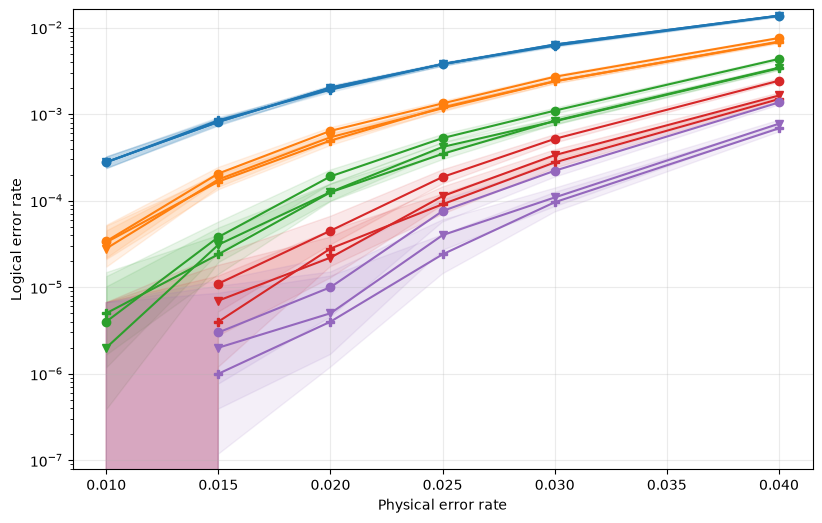

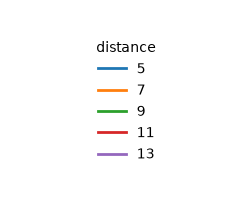

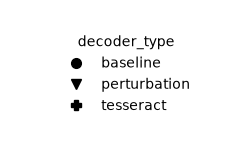

,distance,decoder_type,source_decoder_type,metric,physical_error_rate,shots,failures,logical_error_rate,ler_low,ler_high
0,5,baseline,perturbation,default_logical_error,0.010,1000000,279,0.000279,0.000239,0.000325
1,5,perturbation,perturbation,logical_error,0.010,1000000,279,0.000279,0.000239,0.000325
2,5,tesseract,tesseract,logical_error,0.010,1000000,277,0.000277,0.000237,0.000323
3,5,baseline,perturbation,default_logical_error,0.015,1000000,814,0.000814,0.000744,0.000891
4,5,perturbation,perturbation,logical_error,0.015,1000000,814,0.000814,0.000744,0.000891
...,...,...,...,...,...,...,...,...,...,...
85,13,perturbation,perturbation,logical_error,0.030,1000000,109,0.000109,0.000085,0.000139
86,13,tesseract,tesseract,logical_error,0.030,1000000,96,0.000096,0.000074,0.000125
87,13,baseline,perturbation,default_logical_error,0.040,1000000,1367,0.001367,0.001275,0.001466
88,13,perturbation,perturbation,logical_error,0.040,1000000,776,0.000776,0.000708,0.000851


Saved figures to: /home/quantum_teresheys/workspace/color_code_softoutput/cluster_results/26_09_28_00_17_00_00df6314/analysis


In [4]:
figure, axes, ler_table = run.plot_ler(
    filter=filter,
    group_by=group_by,
    baseline_compare=baseline_compare,
    yscale=yscale,
    plot_width=plot_width,
    plot_height=plot_height,
)
ler_legends = run.plot_legends(ler_table, group_by=group_by, **legend_options)
# Customize independently here, for example:
# axes.set_title("...")
# ler_legends["distance"][0].set_size_inches(2.0, 2.5)
# ler_legends["decoder_type"][1].get_legend().set_title("Decoder")
display(figure)
plt.close(figure)
for legend_figure, legend_axes in ler_legends.values():
    display(legend_figure)
    plt.close(legend_figure)
columns = ["distance", "decoder_type", "physical_error_rate", "shots", "failures", "logical_error_rate", "ler_low", "ler_high"]
if baseline_compare:
    columns[2:2] = ["source_decoder_type", "metric"]
display(ler_table[columns])
if save_figure:
    output_dir = run.run_directory / "analysis"
    output_dir.mkdir(exist_ok=True)
    stem = "color_correlated_ler_with_baseline" if baseline_compare else "color_correlated_ler"
    figures = {stem: figure, **{f"{stem}_legend_{name}": pair[0] for name, pair in ler_legends.items()}}
    for name, saved_figure in figures.items():
        for extension in ("png", "pdf"):
            saved_figure.savefig(output_dir / f"{name}.{extension}", dpi=200, bbox_inches="tight")
    print("Saved figures to:", output_dir)


## LER improvement ratio versus code distance

Choose one `improvement_physical_error_rate` and optional `improvement_filter`. The ratio is **baseline LER / decoder LER**: a value above 1 means fewer logical failures. The dashed line at 1 denotes equal rates. The default x-axis is code distance; `x` can also be `rounds` or `physical_error_rate`.

Paired decoders use their own saved baseline. Decoders without paired metrics (for example Tesseract) use a representative baseline at the same physical conditions, including distance, rounds and noise model. `baseline_paired` and `baseline_point_directory` record that distinction. Infinite ratios (positive baseline and zero decoder LER) and undefined ratios (both zero) remain in the table and have no plotted estimate. No ratio confidence band is inferred from the marginal Wilson intervals.

The distance colors and decoder markers match the LER figure. Both legends are independent figures and can be customized separately.


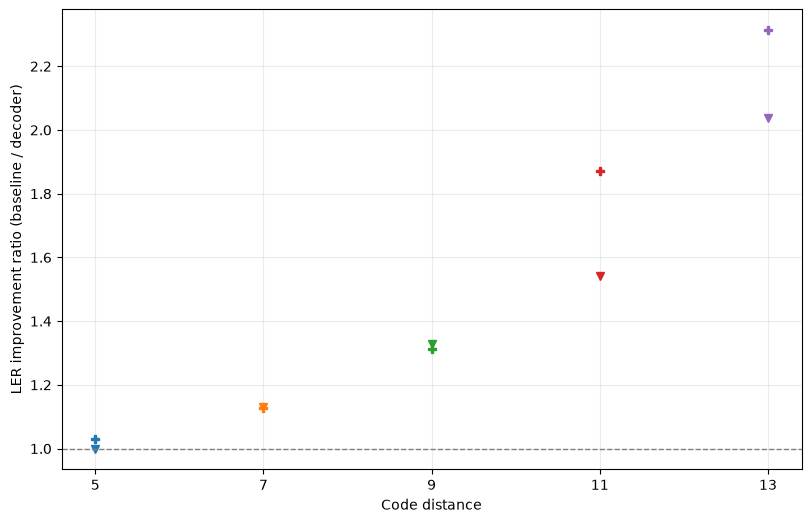

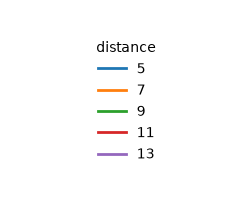

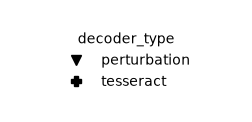

,distance,decoder_type,physical_error_rate,logical_error_rate,baseline_logical_error_rate,improvement_ratio,baseline_paired,baseline_point_directory
0,5,perturbation,0.03,0.006367,0.006367,1.000000,True,"decoder_type=perturbation,circuit_type=tri,d=5..."
1,5,tesseract,0.03,0.006181,0.006367,1.030092,False,"decoder_type=perturbation,circuit_type=tri,d=5..."
2,7,perturbation,0.03,0.002392,0.002704,1.130435,True,"decoder_type=perturbation,circuit_type=tri,d=7..."
3,7,tesseract,0.03,0.002399,0.002704,1.127136,False,"decoder_type=perturbation,circuit_type=tri,d=7..."
4,9,perturbation,0.03,0.000827,0.001098,1.327690,True,"decoder_type=perturbation,circuit_type=tri,d=9..."
5,9,tesseract,0.03,0.000837,0.001098,1.311828,False,"decoder_type=perturbation,circuit_type=tri,d=9..."
6,11,perturbation,0.03,0.000336,0.000518,1.541667,True,"decoder_type=perturbation,circuit_type=tri,d=1..."
7,11,tesseract,0.03,0.000277,0.000518,1.870036,False,"decoder_type=perturbation,circuit_type=tri,d=1..."
8,13,perturbation,0.03,0.000109,0.000222,2.036697,True,"decoder_type=perturbation,circuit_type=tri,d=1..."
9,13,tesseract,0.03,0.000096,0.000222,2.312500,False,"decoder_type=perturbation,circuit_type=tri,d=1..."


Saved figures to: /home/quantum_teresheys/workspace/color_code_softoutput/cluster_results/26_09_28_00_17_00_00df6314/analysis


In [8]:
improvement_filter = filter  # use a separate mapping to select these points
# Choose one saved physical error rate; edit this value as needed.
improvement_physical_error_rate = float(0.03)
improvement_x = "distance"
improvement_group_by = ["distance", "decoder_type"]
improvement_legend_options = dict(fontsize=10, row_height=0.35, width=3.0, ncol=1)

ratio_figure, ratio_axes, ratio_table = run.plot_improvement_ratio(
    physical_error_rate=improvement_physical_error_rate,
    filter=improvement_filter,
    x=improvement_x,
    group_by=improvement_group_by,
    plot_width=plot_width,
    plot_height=plot_height,
)
ratio_legends = run.plot_legends(ratio_table, group_by=improvement_group_by, **improvement_legend_options)
# Customize ratio_axes and each ratio_legends[field] independently here.
display(ratio_figure)
plt.close(ratio_figure)
for legend_figure, legend_axes in ratio_legends.values():
    display(legend_figure)
    plt.close(legend_figure)
display(ratio_table[["distance", "decoder_type", "physical_error_rate", "logical_error_rate",
                     "baseline_logical_error_rate", "improvement_ratio", "baseline_paired",
                     "baseline_point_directory"]])
if save_figure:
    output_dir = run.run_directory / "analysis"
    output_dir.mkdir(exist_ok=True)
    stem = f"color_correlated_improvement_ratio_p{improvement_physical_error_rate:g}"
    figures = {stem: ratio_figure, **{f"{stem}_legend_{name}": pair[0] for name, pair in ratio_legends.items()}}
    for name, saved_figure in figures.items():
        for extension in ("png", "pdf"):
            saved_figure.savefig(output_dir / f"{name}.{extension}", dpi=200, bbox_inches="tight")
    print("Saved figures to:", output_dir)


## Correlated-decoding counts by experiment condition

The first table counts lower-weight candidates. In the second table, `effect_count` counts shots rescued relative to the paired baseline, `worsened_count` counts shots where the baseline succeeded but the selected decoder failed, and `net_effect_count = effect_count - worsened_count`. Positive net values mean fewer logical failures. These counts are blank for ordinary decoder points because paired baseline files are not produced. `shots` is the denominator for each count.

In [6]:
display(run.better_weight_table(filter=better_weight_filter))
display(run.effect_table(filter=effect_filter))


,decoder_type,circuit_type,distance,rounds,physical_error_rate,noise_model,cnot_schedule,shots,better_weight_count
0,perturbation,tri,5,1,0.010,bitflip,tri_optimal,1000000,0
1,tesseract,tri,5,1,0.010,bitflip,tri_optimal,1000000,<NA>
2,perturbation,tri,5,1,0.015,bitflip,tri_optimal,1000000,0
3,tesseract,tri,5,1,0.015,bitflip,tri_optimal,1000000,<NA>
4,perturbation,tri,5,1,0.020,bitflip,tri_optimal,1000000,0
5,tesseract,tri,5,1,0.020,bitflip,tri_optimal,1000000,<NA>
6,perturbation,tri,5,1,0.025,bitflip,tri_optimal,1000000,0
7,tesseract,tri,5,1,0.025,bitflip,tri_optimal,1000000,<NA>
8,perturbation,tri,5,1,0.030,bitflip,tri_optimal,1000000,0
9,tesseract,tri,5,1,0.030,bitflip,tri_optimal,1000000,<NA>


,decoder_type,circuit_type,distance,rounds,physical_error_rate,noise_model,cnot_schedule,shots,effect_count,worsened_count,net_effect_count
0,perturbation,tri,5,1,0.010,bitflip,tri_optimal,1000000,0,0,0
1,tesseract,tri,5,1,0.010,bitflip,tri_optimal,1000000,<NA>,<NA>,<NA>
2,perturbation,tri,5,1,0.015,bitflip,tri_optimal,1000000,0,0,0
3,tesseract,tri,5,1,0.015,bitflip,tri_optimal,1000000,<NA>,<NA>,<NA>
4,perturbation,tri,5,1,0.020,bitflip,tri_optimal,1000000,0,0,0
5,tesseract,tri,5,1,0.020,bitflip,tri_optimal,1000000,<NA>,<NA>,<NA>
6,perturbation,tri,5,1,0.025,bitflip,tri_optimal,1000000,0,0,0
7,tesseract,tri,5,1,0.025,bitflip,tri_optimal,1000000,<NA>,<NA>,<NA>
8,perturbation,tri,5,1,0.030,bitflip,tri_optimal,1000000,0,0,0
9,tesseract,tri,5,1,0.030,bitflip,tri_optimal,1000000,<NA>,<NA>,<NA>
